**Step-01: Data ingestion and AAMI Mapping**

In [1]:
# ============================================================
# STEP-01: Data ingestion, AAMI Mapping + R-peak Preservation
# ============================================================
!pip install wfdb scikit-learn imbalanced-learn matplotlib seaborn -q

import os
import pickle
import numpy as np
import wfdb

# --- AAMI standard 5-class mapping ---
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

CLASS2IDX  = {'N':0, 'S':1, 'V':2, 'F':3, 'Q':4}
IDX2CLASS  = {0:'N', 1:'S', 2:'V', 3:'F', 4:'Q'}
CLASS_NAMES = ['N','S','V','F','Q']

# All 48 MIT-BIH records
MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]


def load_record(record_id, data_dir='mitdb'):
    path   = os.path.join(data_dir, record_id)
    record = wfdb.rdrecord(path)
    annot  = wfdb.rdann(path, 'atr')
    return record.p_signal, record.fs, annot.sample, annot.symbol


def extract_beats(signal, fs, r_peaks, symbols, before=150, after=150):
    """
    Extract fixed-length beat windows around each R-peak.

    Returns
    -------
    beats           : (N, win, 2) float32
    labels          : (N,) int64
    r_peaks_kept    : (N,) int64  — R-peak sample indices in ORIGINAL signal
                                    that correspond to each extracted beat
    """
    beats, labels, r_peaks_kept = [], [], []
    win = before + after
    for peak, sym in zip(r_peaks, symbols):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start, end = peak - before, peak + after
        if start < 0 or end > signal.shape[0]:
            continue
        beats.append(signal[start:end, :])
        labels.append(CLASS2IDX[aami])
        r_peaks_kept.append(int(peak))

    if len(labels) == 0:
        return (np.empty((0, win, 2), dtype=np.float32),
                np.empty((0,), dtype=np.int64),
                np.empty((0,), dtype=np.int64))
    return (np.array(beats, dtype=np.float32),
            np.array(labels, dtype=np.int64),
            np.array(r_peaks_kept, dtype=np.int64))


def download_and_extract():
    os.makedirs('mitdb', exist_ok=True)
    os.makedirs('processed', exist_ok=True)

    if os.path.exists('processed/subject_data.pkl'):
        print('subject_data.pkl already exists — skipping download.')
        with open('processed/subject_data.pkl','rb') as f:
            return pickle.load(f)

    print('Downloading MIT-BIH...')
    wfdb.dl_database('mitdb', dl_dir='mitdb',
                     records=MIT_BIH_RECORDS, overwrite=False)
    print('Download complete.')

    subject_data = {}
    for rec in MIT_BIH_RECORDS:
        signal, fs, r_peaks, symbols = load_record(rec)
        beats, labels, r_peaks_kept = extract_beats(signal, fs, r_peaks, symbols)
        subject_data[rec] = {
            'beats'   : beats,
            'labels'  : labels,
            'r_peaks' : r_peaks_kept,     # ← NEW: kept R-peak sample indices
            'fs'      : int(fs)           # ← NEW: sampling frequency (needed for rhythm)
        }
        if len(labels) > 0:
            print(f'  {rec}: {len(labels)} beats | fs={fs} | '
                  f'{np.bincount(labels, minlength=5)}')

    with open('processed/subject_data.pkl','wb') as f:
        pickle.dump(subject_data, f)
    print('Saved: processed/subject_data.pkl')
    return subject_data


subject_data = download_and_extract()
print(f'\nLoaded {len(subject_data)} records.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.6 MB/s eta 0:00:00 0:00:01
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating recor

**Step-02: Leak Free LOSO Fold Builder**

In [2]:
import pickle
import numpy as np


# ---------------------------------------------------------------------
# PATIENT MAPPING
# In the MIT-BIH Arrhythmia Database, every record maps to a unique
# patient EXCEPT records 201 and 202, which come from the same subject
# (per the official database documentation). Grouping by patient_id
# instead of record_id ensures a true leave-one-subject-out (LOSO)
# split -- no patient's beats can appear in both train and test.
# ---------------------------------------------------------------------
def build_patient_groups(record_ids):
    """Map each record_id to a patient_id, merging the one known
    same-patient pair (201, 202) into a single patient group."""
    patient_of = {}
    for r in record_ids:
        patient_of[r] = r  # default: record_id == patient_id

    if '201' in patient_of and '202' in patient_of:
        patient_of['202'] = '201'  # 202 belongs to the same patient as 201

    groups = {}
    for r, pid in patient_of.items():
        groups.setdefault(pid, []).append(r)
    return groups  # {patient_id: [record_id, ...]}


def fit_normalize_train(X_train):
    # X_train: (N, C, T)  ->  mean/std shape (1, C, 1)
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    return (X_train - mean) / std, mean, std


def normalize_test(X_test, mean, std):
    return (X_test - mean) / std


def build_loso_folds(subject_data):
    """True leave-one-SUBJECT-out folds: all records belonging to the
    same patient are held out together, so no patient's beats ever
    appear in both the training and test sets of a fold."""
    record_ids = list(subject_data.keys())
    patient_groups = build_patient_groups(record_ids)
    patient_ids = list(patient_groups.keys())

    folds = []

    for i, test_patient in enumerate(patient_ids):
        test_records  = patient_groups[test_patient]
        train_records = [r for r in record_ids if r not in test_records]

        # FIX: use .shape[0] (reliable for numpy even on empty arrays)
        X_train_list = [subject_data[r]['beats']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]
        y_train_list = [subject_data[r]['labels']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]

        X_test_list = [subject_data[r]['beats']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]
        y_test_list = [subject_data[r]['labels']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]

        if len(X_train_list) == 0 or len(X_test_list) == 0:
            print(f"Skipping fold {test_patient} (empty data)")
            continue

        X_train = np.concatenate(X_train_list, axis=0)  # (N, 300, 2)
        y_train = np.concatenate(y_train_list, axis=0)
        X_test  = np.concatenate(X_test_list, axis=0)   # (M, 300, 2)
        y_test  = np.concatenate(y_test_list, axis=0)

        X_train = X_train.transpose(0, 2, 1)  # (N, 2, 300)
        X_test  = X_test.transpose(0, 2, 1)   # (M, 2, 300)

        X_train_norm, mean, std = fit_normalize_train(X_train)
        X_test_norm             = normalize_test(X_test, mean, std)

        folds.append({
            "test_id" : "+".join(test_records),  # e.g. "201+202"
            "patient_id": test_patient,
            "X_train" : X_train_norm.astype(np.float32),
            "y_train" : y_train.astype(np.int64),
            "X_test"  : X_test_norm.astype(np.float32),
            "y_test"  : y_test.astype(np.int64),
            "mean"    : mean,
            "std"     : std
        })
        print(f"Fold {i+1:02d} | test_patient={test_patient} "
              f"(records={'+'.join(test_records)}) | "
              f"train={X_train_norm.shape[0]} | "
              f"test={X_test_norm.shape[0]}")

    return folds


if __name__ == "__main__":
    with open("processed/subject_data.pkl", "rb") as f:
        subject_data = pickle.load(f)
    folds = build_loso_folds(subject_data)
    with open("processed/loso_folds.pkl", "wb") as f:
        pickle.dump(folds, f)
    print(f"Saved processed/loso_folds.pkl ({len(folds)} true patient-independent folds)")

Fold 01 | test_patient=100 (records=100) | train=107173 | test=2271
Fold 02 | test_patient=101 (records=101) | train=107580 | test=1864
Fold 03 | test_patient=102 (records=102) | train=107259 | test=2185
Fold 04 | test_patient=103 (records=103) | train=107361 | test=2083
Fold 05 | test_patient=104 (records=104) | train=107217 | test=2227
Fold 06 | test_patient=105 (records=105) | train=106872 | test=2572
Fold 07 | test_patient=106 (records=106) | train=107417 | test=2027
Fold 08 | test_patient=107 (records=107) | train=107308 | test=2136
Fold 09 | test_patient=108 (records=108) | train=107682 | test=1762
Fold 10 | test_patient=109 (records=109) | train=106914 | test=2530
Fold 11 | test_patient=111 (records=111) | train=107320 | test=2124
Fold 12 | test_patient=112 (records=112) | train=106907 | test=2537
Fold 13 | test_patient=113 (records=113) | train=107650 | test=1794
Fold 14 | test_patient=114 (records=114) | train=107565 | test=1879
Fold 15 | test_patient=115 (records=115) | train

**Step-03: Fold Local Normalization and Imbalance Handling**

In [3]:
# ============================================================
# STEP-03: Fold-local imbalance handling utilities
# ============================================================
import pickle

with open("processed/loso_folds.pkl", "rb") as f:
    folds = pickle.load(f)

print(f"Loaded {len(folds)} folds")
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


def get_class_weight_dict(y_train):
    """
    Compute sklearn-style balanced class weights
    from TRAINING data only.
    """

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    return {
        int(cls): float(w)
        for cls, w in zip(classes, weights)
    }


def print_fold_statistics(fold):
    """
    Display fold-specific class distribution and weights.
    """

    y_train = fold["y_train"]

    print("=" * 60)
    print("Training Class Distribution")
    print("=" * 60)

    counts = Counter(y_train)

    for cls_idx in range(5):
        cls_name = CLASS_NAMES[cls_idx]
        count = counts.get(cls_idx, 0)

        print(
            f"Class {cls_name} ({cls_idx}) : {count}"
        )

    class_weights = get_class_weight_dict(y_train)

    print("\nBalanced Class Weights")
    print("-" * 60)

    for cls_idx in range(5):
        cls_name = CLASS_NAMES[cls_idx]

        if cls_idx in class_weights:
            print(
                f"Class {cls_name} ({cls_idx}) : "
                f"{class_weights[cls_idx]:.4f}"
            )

    return class_weights


# ============================================================
# Example: inspect first fold
# ============================================================

fold0 = folds[0]

class_weights = print_fold_statistics(fold0)

print("\nClass Weight Dictionary:")
print(class_weights)

Loaded 47 folds
Training Class Distribution
Class N (0) : 88351
Class S (1) : 2748
Class V (2) : 7234
Class F (3) : 802
Class Q (4) : 8038

Balanced Class Weights
------------------------------------------------------------
Class N (0) : 0.2426
Class S (1) : 7.8001
Class V (2) : 2.9630
Class F (3) : 26.7264
Class Q (4) : 2.6667

Class Weight Dictionary:
{0: 0.24260732759108555, 1: 7.800072780203784, 2: 2.963035664915676, 3: 26.72643391521197, 4: 2.6666583727295348}


**Step-04: Feature Extraction**

In [4]:
# ============================================================
# STEP-04: DUAL-SCALE FEATURE EXTRACTION
#   Scale 1 (Intra-beat)  : 38 morphology features
#   Scale 2 (Inter-beat)  : 17 TRUE RR-interval RHYTHM features
# ============================================================

import numpy as np
from scipy.stats import skew, kurtosis


# ============================================================
#  BASIC SAFE HELPERS
# ============================================================
def safe_mean(x):   return float(np.mean(x))
def safe_std(x):    return float(np.std(x))
def safe_min(x):    return float(np.min(x))
def safe_max(x):    return float(np.max(x))
def safe_range(x):  return float(np.max(x) - np.min(x))
def safe_rms(x):    return float(np.sqrt(np.mean(x ** 2)))
def safe_median(x): return float(np.median(x))

def safe_iqr(x):
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)

def safe_energy(x): return float(np.mean(x ** 2))

def safe_skew(x):
    v = skew(x, bias=False)
    return 0.0 if not np.isfinite(v) else float(v)

def safe_kurtosis(x):
    v = kurtosis(x, bias=False)
    return 0.0 if not np.isfinite(v) else float(v)

def safe_zero_crossing_rate(x):
    if len(x) < 2:
        return 0.0
    signs = np.sign(x)
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    crossings = np.sum(signs[1:] != signs[:-1])
    return float(crossings / max(1, len(x) - 1))

def safe_mean_abs_diff(x):
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

def safe_std_diff(x):
    if len(x) < 2:
        return 0.0
    return float(np.std(np.diff(x)))

def safe_correlation(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if len(x) != len(y) or len(x) < 2:
        return 0.0
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0
    v = np.corrcoef(x, y)[0, 1]
    return 0.0 if not np.isfinite(v) else float(v)


# ============================================================
#  SCALE-1 : INTRA-BEAT MORPHOLOGY (18 per lead + 2 cross = 38)
# ============================================================
def extract_single_lead_features(signal):
    signal = np.asarray(signal, dtype=np.float64)
    signal = np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0)

    features = []
    features.append(safe_mean(signal))
    features.append(safe_std(signal))
    features.append(safe_min(signal))
    features.append(safe_max(signal))
    features.append(safe_range(signal))
    features.append(safe_rms(signal))
    features.append(safe_median(signal))
    features.append(safe_iqr(signal))
    features.append(safe_skew(signal))
    features.append(safe_kurtosis(signal))
    features.append(safe_energy(signal))
    features.append(safe_zero_crossing_rate(signal))
    features.append(safe_mean_abs_diff(signal))
    features.append(safe_std_diff(signal))
    features.append(float(np.max(np.abs(signal))))
    features.append(float(np.mean(np.abs(signal))))

    peak_position = np.argmax(np.abs(signal))
    if len(signal) > 1:
        peak_position = peak_position / (len(signal) - 1)
    else:
        peak_position = 0.0
    features.append(float(peak_position))

    t = np.arange(len(signal), dtype=np.float64)
    if len(signal) > 1 and np.std(t) > 0:
        slope = np.polyfit(t, signal, 1)[0]
    else:
        slope = 0.0
    if not np.isfinite(slope):
        slope = 0.0
    features.append(float(slope))

    return np.asarray(features, dtype=np.float32)


def extract_features(X):
    """Extract 38 intra-beat morphology features. X: (N, 2, 300) → (N, 38)."""
    X = np.asarray(X)
    if X.ndim != 3 or X.shape[1] != 2 or X.shape[2] != 300:
        raise ValueError(f"Expected (N, 2, 300), got {X.shape}")

    feature_list = []
    for i in range(X.shape[0]):
        beat = np.nan_to_num(X[i].astype(np.float64),
                             nan=0.0, posinf=0.0, neginf=0.0)
        l1 = extract_single_lead_features(beat[0])
        l2 = extract_single_lead_features(beat[1])
        cross_corr = safe_correlation(beat[0], beat[1])
        cross_diff = float(np.mean(np.abs(beat[0] - beat[1])))
        combined = np.concatenate([
            l1, l2,
            np.array([cross_corr, cross_diff], dtype=np.float32)
        ])
        feature_list.append(combined)

    features = np.asarray(feature_list, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    return features


# ============================================================
#  SCALE-2 : INTER-BEAT TRUE RHYTHM (RR-INTERVAL) FEATURES
#            17 features, purely temporal — NO waveform info
# ============================================================
def get_context_window(idx, N, context_size=8):
    """Return neighbor indices around focal beat (reflected at edges)."""
    if N <= 1:
        return []
    half = context_size // 2
    indices = []
    for offset in range(-half, half + 1):
        if offset == 0:
            continue
        j = idx + offset
        if j < 0:
            j = -j
        elif j >= N:
            j = 2 * N - j - 2
        j = max(0, min(N - 1, j))
        if j != idx:
            indices.append(j)
    return indices


def extract_rhythm_features(focal_idx, r_peaks, fs, context_size=8):
    """
    Extract 17 TRUE RR-interval rhythm features for one beat.

    Parameters
    ----------
    focal_idx    : int   — index of current beat in r_peaks array
    r_peaks      : (N,)  — R-peak sample indices for this record
    fs           : int   — sampling frequency (Hz)
    context_size : int   — number of neighbors used for local rhythm stats

    Notes
    -----
    All 17 features are purely temporal (derived from R-peak timing),
    containing NO waveform / morphology information.
    """
    r_peaks = np.asarray(r_peaks, dtype=np.float64)
    N = len(r_peaks)

    # If we can't compute rhythm reliably → all zeros
    if N < 3:
        return np.zeros(17, dtype=np.float32)

    # -------- RR intervals in SECONDS --------
    rr_all = np.diff(r_peaks) / float(fs)          # length N-1

    # RR interval BEFORE focal beat (pre-RR)
    if focal_idx >= 1:
        pre_rr = (r_peaks[focal_idx] - r_peaks[focal_idx - 1]) / fs
    else:
        pre_rr = float(np.mean(rr_all))

    # RR interval AFTER focal beat (post-RR)
    if focal_idx <= N - 2:
        post_rr = (r_peaks[focal_idx + 1] - r_peaks[focal_idx]) / fs
    else:
        post_rr = float(np.mean(rr_all))

    # -------- Local context RR window --------
    ctx_idx = get_context_window(focal_idx, N, context_size=context_size)
    local_rr = []
    for j in ctx_idx:
        if j >= 1:
            local_rr.append((r_peaks[j] - r_peaks[j - 1]) / fs)
    local_rr = np.asarray(local_rr, dtype=np.float64)
    if len(local_rr) == 0:
        local_rr = rr_all.copy()

    # Successive differences within local window
    local_diff = np.diff(local_rr) if len(local_rr) >= 2 else np.array([0.0])

    feats = []

    # ---- Focal-beat rhythm (4) ----
    feats.append(float(pre_rr))                                   # 1. pre-RR
    feats.append(float(post_rr))                                  # 2. post-RR
    feats.append(float(post_rr - pre_rr))                         # 3. RR delta
    feats.append(float(post_rr / (pre_rr + 1e-8)))                # 4. RR ratio

    # ---- Local RR statistics (7) ----
    feats.append(float(np.mean(local_rr)))                        # 5
    feats.append(float(np.std(local_rr)))                         # 6
    feats.append(float(np.min(local_rr)))                         # 7
    feats.append(float(np.max(local_rr)))                         # 8
    feats.append(float(np.median(local_rr)))                      # 9
    q75, q25 = np.percentile(local_rr, [75, 25])
    feats.append(float(q75 - q25))                                # 10  IQR
    feats.append(float(np.max(local_rr) - np.min(local_rr)))      # 11  range

    # ---- HRV-style rhythm variability (3) ----
    feats.append(float(np.sqrt(np.mean(local_diff ** 2))))        # 12  RMSSD
    feats.append(float(np.std(local_diff)))                       # 13  SDSD
    pnn50 = float(np.mean(np.abs(local_diff) > 0.05))             # 14  pNN50 (>50 ms)
    feats.append(pnn50)

    # ---- Focal vs local context (2) ----
    local_mean = float(np.mean(local_rr))
    feats.append(float(pre_rr / (local_mean + 1e-8)))             # 15  normalized pre-RR
    feats.append(float(pre_rr - local_mean))                      # 16  deviation from local mean

    # ---- Instantaneous heart rate (1) ----
    hr = 60.0 / (pre_rr + 1e-8)                                   # 17  HR in BPM
    feats.append(float(hr))

    feats = np.asarray(feats, dtype=np.float32)
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    return feats


# ============================================================
#  FULL DUAL-SCALE EXTRACTION (Morphology + Rhythm)
# ============================================================
def extract_features_dual_scale(X, r_peaks, fs, context_size=8):
    """
    Dual-scale feature extractor.

    Parameters
    ----------
    X            : (N, 2, 300)  ECG beats
    r_peaks      : (N,)         R-peak sample indices for those N beats
                                (from the SAME record only)
    fs           : int          sampling frequency of that record
    context_size : int          rhythm-window size (default 8)

    Returns
    -------
    (N, 55) : 38 morphology + 17 rhythm
    """
    X = np.asarray(X)
    r_peaks = np.asarray(r_peaks, dtype=np.int64)

    if X.ndim != 3 or X.shape[1] != 2 or X.shape[2] != 300:
        raise ValueError(f"Expected (N, 2, 300), got {X.shape}")
    if len(r_peaks) != X.shape[0]:
        raise ValueError(
            f"r_peaks length ({len(r_peaks)}) must match "
            f"number of beats ({X.shape[0]})."
        )

    N = X.shape[0]

    # ---- Scale 1: intra-beat morphology (38) ----
    intra_features = extract_features(X)
    if intra_features.shape != (N, 38):
        raise RuntimeError(
            f"Intra-beat features shape mismatch: {intra_features.shape}"
        )

    # ---- Scale 2: inter-beat true rhythm (17) ----
    inter_list = []
    for i in range(N):
        inter_list.append(
            extract_rhythm_features(
                focal_idx=i,
                r_peaks=r_peaks,
                fs=fs,
                context_size=context_size
            )
        )
    inter_features = np.asarray(inter_list, dtype=np.float32)
    if inter_features.shape != (N, 17):
        raise RuntimeError(
            f"Inter-beat rhythm shape mismatch: {inter_features.shape}"
        )

    # ---- Fusion ----
    dual_features = np.concatenate([intra_features, inter_features], axis=1)
    dual_features = np.nan_to_num(dual_features, nan=0.0,
                                  posinf=0.0, neginf=0.0).astype(np.float32)

    if dual_features.shape != (N, 55):
        raise RuntimeError(f"Dual-scale shape mismatch: {dual_features.shape}")

    return dual_features


# ============================================================
#  TEST / VALIDATION
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("STEP-04 DUAL-SCALE (Morphology + True Rhythm) TEST")
    print("=" * 60)

    X_test = np.random.randn(20, 2, 300).astype(np.float32)

    # Simulate R-peaks ~1 second apart at 360 Hz
    fs_test = 360
    r_peaks_test = np.cumsum(
        np.random.randint(280, 400, size=20)
    ).astype(np.int64)

    intra = extract_features(X_test)
    print("Intra-beat feature shape :", intra.shape)

    dual = extract_features_dual_scale(
        X_test,
        r_peaks=r_peaks_test,
        fs=fs_test,
        context_size=8
    )
    print("Dual-scale feature shape :", dual.shape)

    assert intra.shape == (20, 38)
    assert dual.shape  == (20, 55)
    assert np.isfinite(intra).all()
    assert np.isfinite(dual).all()

    print("✓ Intra-beat (morphology) : 38")
    print("✓ Inter-beat (rhythm)     : 17")
    print("✓ Dual-scale total        : 55")
    print("✓ No NaN / Inf")
    print("=" * 60)

STEP-04 DUAL-SCALE (Morphology + True Rhythm) TEST
Intra-beat feature shape : (20, 38)
Dual-scale feature shape : (20, 55)
✓ Intra-beat (morphology) : 38
✓ Inter-beat (rhythm)     : 17
✓ Dual-scale total        : 55
✓ No NaN / Inf


**Step-05: Decision Tree and LOSO Evaluation**

In [5]:
# ============================================================
# STEP-05: Decision Tree Training + LOSO Evaluation
#          (Morphology 38-D  +  True Rhythm 17-D  =  55-D)
# ============================================================

import os
import pickle
import time
import warnings
from collections import Counter

import numpy as np
import wfdb
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

CRITERION         = "gini"
MAX_DEPTH         = 20
MIN_SAMPLES_SPLIT = 10
MIN_SAMPLES_LEAF  = 5


# ------------------------------------------------------------
# 1. PRE-EXTRACT FEATURES PER RECORD (leak-free)
# ------------------------------------------------------------
print("=" * 70)
print("PRE-EXTRACTING 55-D (MORPHOLOGY + RHYTHM) FEATURES PER RECORD...")
print("=" * 70)
start_pre = time.time()

record_features_cache = {}

for rec in MIT_BIH_RECORDS:
    path = os.path.join('mitdb', rec)
    record = wfdb.rdrecord(path)
    annot  = wfdb.rdann(path, 'atr')
    sig     = record.p_signal
    fs      = int(record.fs)
    sig_len = sig.shape[0]

    beats, labels, r_peaks_kept = [], [], []
    for peak, sym in zip(annot.sample, annot.symbol):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start, end = peak - 150, peak + 150
        if start < 0 or end > sig_len:
            continue
        beats.append(sig[start:end, :])
        labels.append({'N':0, 'S':1, 'V':2, 'F':3, 'Q':4}[aami])
        r_peaks_kept.append(int(peak))

    if len(labels) == 0:
        continue

    X_rec       = np.array(beats, dtype=np.float32).transpose(0, 2, 1)  # (N, 2, 300)
    y_rec       = np.array(labels, dtype=np.int64)
    r_peaks_rec = np.array(r_peaks_kept, dtype=np.int64)

    # Called per-record with per-record R-peaks and fs →
    # rhythm features can never bleed across patients.
    feat_rec = extract_features_dual_scale(
        X_rec,
        r_peaks=r_peaks_rec,
        fs=fs,
        context_size=8
    )
    feat_rec = np.nan_to_num(
        feat_rec, nan=0.0, posinf=0.0, neginf=0.0
    ).astype(np.float32)

    record_features_cache[rec] = {
        "features": feat_rec,
        "labels"  : y_rec
    }

print(f"Pre-extraction complete in {time.time() - start_pre:.2f} seconds.")

# ------------------------------------------------------------
# 2. LOAD LOSO FOLDS
# ------------------------------------------------------------
if 'folds' not in locals() and 'folds' not in globals():
    with open("processed/loso_folds.pkl", "rb") as f:
        folds = pickle.load(f)

# ------------------------------------------------------------
# 3. LOSO EVALUATION LOOP
# ------------------------------------------------------------
print("\n" + "=" * 70)
print(f"RUNNING {len(folds)} LOSO FOLDS (DECISION TREE)...")
print("=" * 70)
start_loso = time.time()
all_results = []

for i, fold in enumerate(folds):

    print(f"\n{'='*70}")
    print(f"Fold {i+1}/{len(folds)} | Test Subject = {fold['test_id']}")
    print(f"{'='*70}")

    test_records  = fold["test_id"].split("+")
    train_records = [r for r in MIT_BIH_RECORDS if r not in test_records]

    X_train_feat = np.concatenate(
        [record_features_cache[r]["features"]
         for r in train_records if r in record_features_cache],
        axis=0
    )
    y_train = np.concatenate(
        [record_features_cache[r]["labels"]
         for r in train_records if r in record_features_cache],
        axis=0
    )

    X_test_feat = np.concatenate(
        [record_features_cache[r]["features"]
         for r in test_records if r in record_features_cache],
        axis=0
    )
    y_test = np.concatenate(
        [record_features_cache[r]["labels"]
         for r in test_records if r in record_features_cache],
        axis=0
    )

    print("\nBefore SMOTE:")
    print(dict(Counter(y_train)))

    # ---- SMOTE on training data only ----
    class_counts   = Counter(y_train)
    min_class_size = min(class_counts.values())

    if min_class_size > 1:
        k_neighbors = min(3, min_class_size - 1)
        smote = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=k_neighbors,
            random_state=42
        )
        X_train_bal, y_train_bal = smote.fit_resample(X_train_feat, y_train)
    else:
        print("SMOTE skipped (a class has only one sample).")
        X_train_bal, y_train_bal = X_train_feat, y_train

    print("\nAfter SMOTE:")
    print(dict(Counter(y_train_bal)))

    # ---- Decision Tree ----
    dt = DecisionTreeClassifier(
        criterion=CRITERION,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=42
    )
    dt.fit(X_train_bal, y_train_bal)

    preds       = dt.predict(X_test_feat)
    preds_proba = dt.predict_proba(X_test_feat)

    if preds_proba.shape[1] < 5:
        full_proba = np.zeros((preds_proba.shape[0], 5))
        for idx, cls in enumerate(dt.classes_):
            full_proba[:, int(cls)] = preds_proba[:, idx]
        preds_proba = full_proba

    acc      = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    cm       = confusion_matrix(y_test, preds, labels=[0,1,2,3,4])
    report   = classification_report(
        y_test, preds, labels=[0,1,2,3,4],
        target_names=CLASS_NAMES, zero_division=0
    )

    print(f"\nAccuracy : {acc:.4f}")
    print(f"Macro-F1 : {macro_f1:.4f}")
    print("\nClassification Report:")
    print(report)

    all_results.append({
        "fold": i + 1,
        "test_id": fold["test_id"],
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "confusion_matrix": cm.tolist(),
        "labels": y_test.tolist(),
        "preds" : preds.tolist(),
        "probs" : preds_proba.tolist(),
        "depth" : int(dt.get_depth()),
        "n_leaves": int(dt.get_n_leaves()),
        "feature_importances": dt.feature_importances_.tolist()
    })


# ------------------------------------------------------------
# 4. FINAL AGGREGATE LOSO REPORT
# ------------------------------------------------------------
all_true = np.concatenate([np.asarray(r["labels"]) for r in all_results])
all_pred = np.concatenate([np.asarray(r["preds"])  for r in all_results])

print(f"\n{'='*70}")
print("LOSO EVALUATION COMPLETE (DECISION TREE, MORPHOLOGY + RHYTHM)")
print(f"Total Folds Evaluated: {len(all_results)}")
print(f"{'='*70}")
print(f"Overall Accuracy : {accuracy_score(all_true, all_pred):.4f}")
print(f"Overall Macro-F1 : "
      f"{f1_score(all_true, all_pred, average='macro', zero_division=0):.4f}\n")
print(classification_report(
    all_true, all_pred, labels=[0,1,2,3,4],
    target_names=CLASS_NAMES, zero_division=0
))
print("=" * 70)

PRE-EXTRACTING 55-D (MORPHOLOGY + RHYTHM) FEATURES PER RECORD...
Pre-extraction complete in 448.16 seconds.

RUNNING 47 LOSO FOLDS (DECISION TREE)...

Fold 1/47 | Test Subject = 100

Before SMOTE:
{np.int64(0): 88351, np.int64(4): 8038, np.int64(1): 2748, np.int64(2): 7234, np.int64(3): 802}

After SMOTE:
{np.int64(0): 88351, np.int64(4): 88351, np.int64(1): 88351, np.int64(2): 88351, np.int64(3): 88351}

Accuracy : 0.3078
Macro-F1 : 0.4507

Classification Report:
              precision    recall  f1-score   support

           N       0.98      0.31      0.47      2237
           S       0.78      0.21      0.33        33
           V       1.00      1.00      1.00         1
           F       0.00      0.00      0.00         0
           Q       0.00      0.00      0.00         0

    accuracy                           0.31      2271
   macro avg       0.55      0.30      0.36      2271
weighted avg       0.97      0.31      0.47      2271


Fold 2/47 | Test Subject = 101

Before SM

**Step-06: Agregate Result and Visualization**

DECISION TREE — OVERALL LOSO RESULTS (MORPHOLOGY + RHYTHM)
Overall Accuracy : 0.7676
Overall Macro-F1 : 0.3952

Classification Report

              precision    recall  f1-score   support

           N       0.91      0.84      0.87     90588
           S       0.09      0.21      0.13      2781
           V       0.54      0.75      0.63      7235
           F       0.02      0.12      0.04       802
           Q       0.37      0.27      0.31      8038

    accuracy                           0.77    109444
   macro avg       0.39      0.44      0.40    109444
weighted avg       0.82      0.77      0.79    109444

Saved: results_dt/all_results.pkl
Saved: results_dt/summary.json


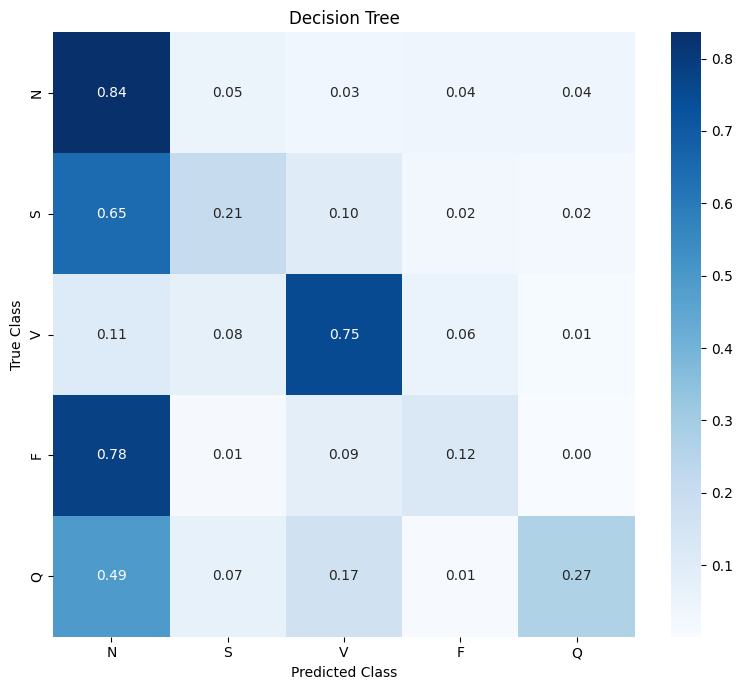

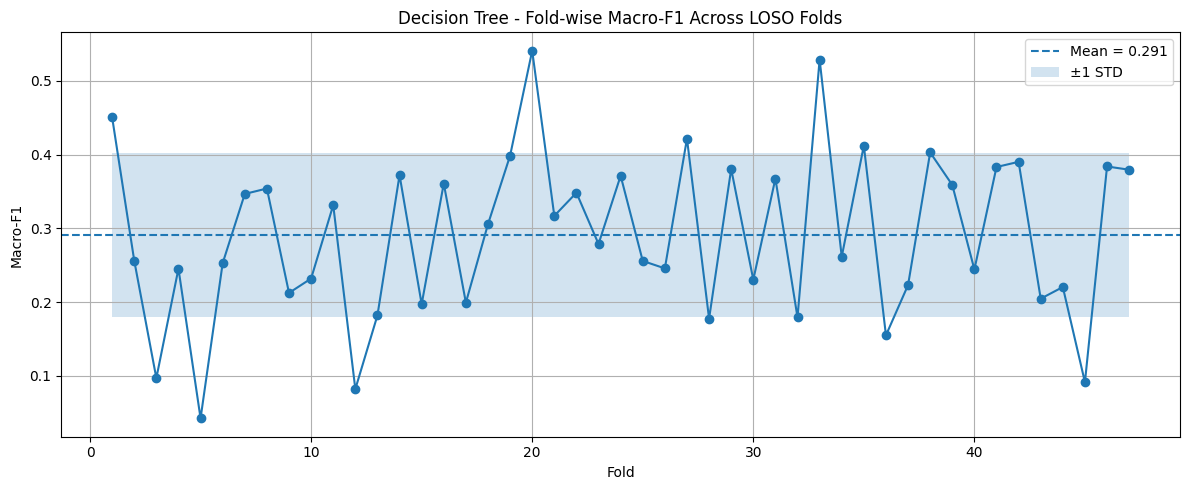

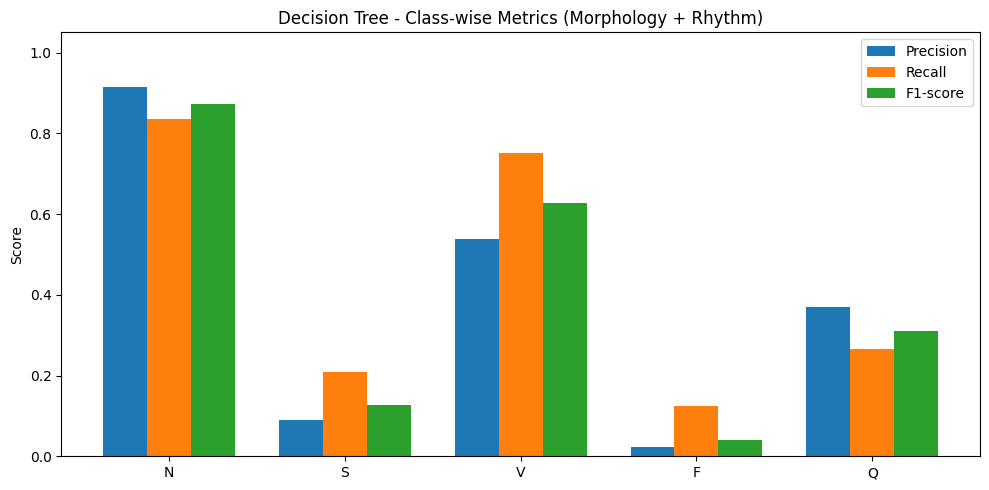

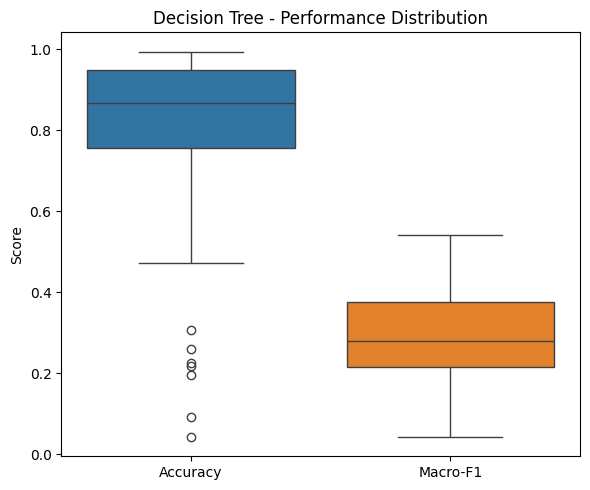

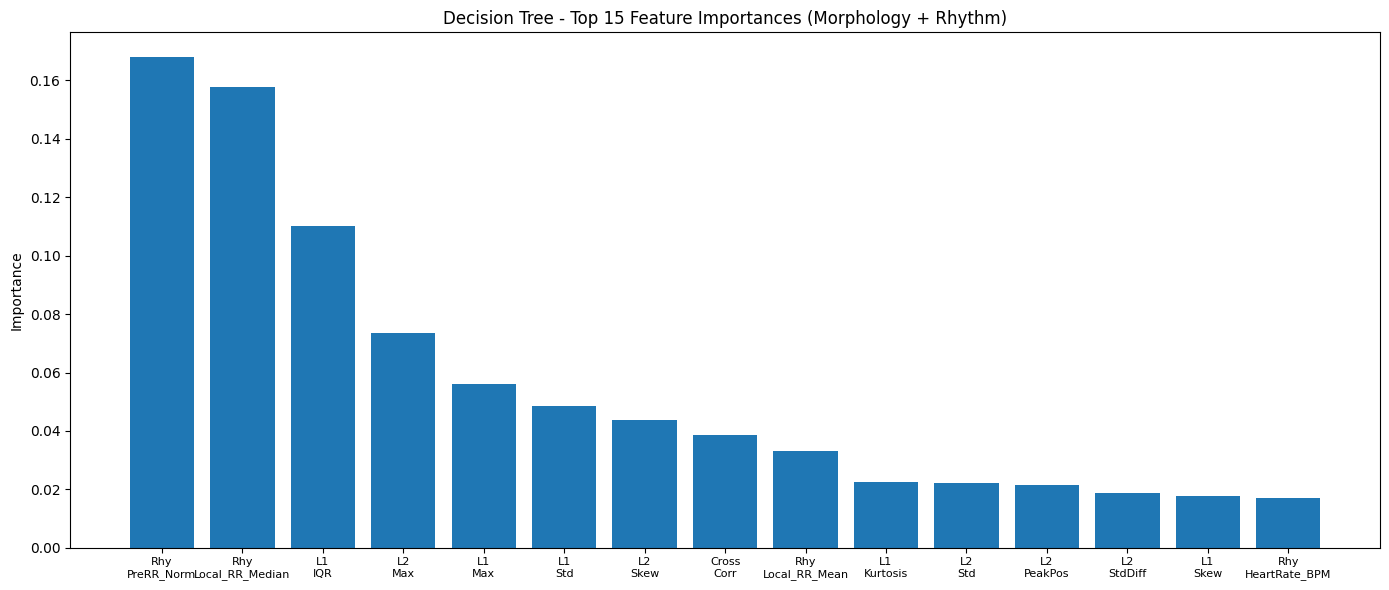

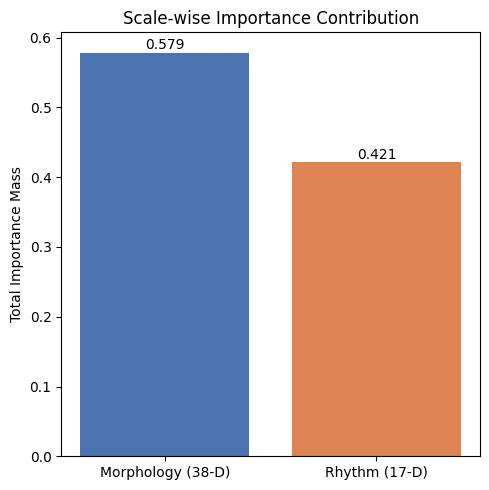

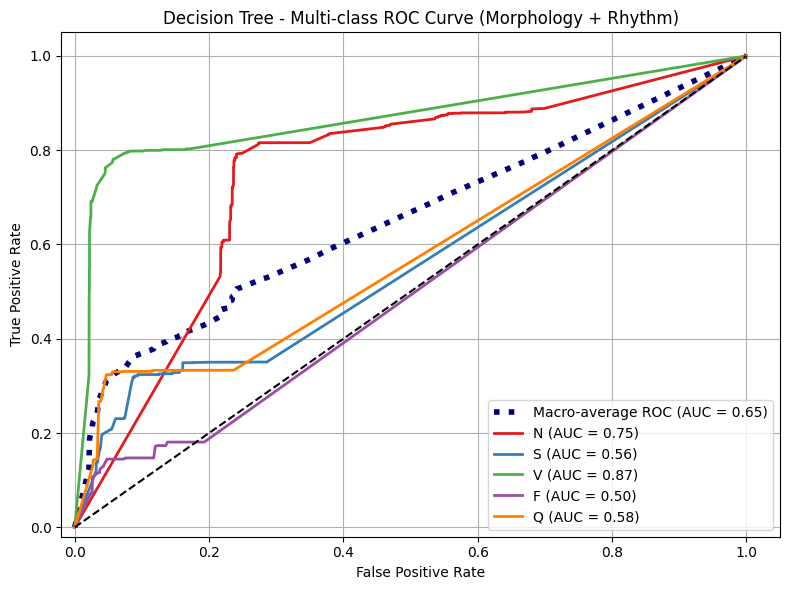


FINAL LOSO PERFORMANCE (MORPHOLOGY 38-D + RHYTHM 17-D)
Overall Accuracy : 0.7676
Overall Macro-F1 : 0.3952


In [6]:
# ============================================================
# STEP-06: Aggregate LOSO Results + Visualization
#          (Morphology 38-D + True Rhythm 17-D)
# ============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------
os.makedirs("results_dt", exist_ok=True)

# ------------------------------------------------------------
# Aggregate predictions
# ------------------------------------------------------------
all_preds  = np.concatenate([np.asarray(r["preds"])  for r in all_results])
all_labels = np.concatenate([np.asarray(r["labels"]) for r in all_results])
all_probs  = np.concatenate([np.asarray(r["probs"])  for r in all_results])

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------
overall_acc = accuracy_score(all_labels, all_preds)
overall_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)

report_dict = classification_report(
    all_labels, all_preds, labels=[0,1,2,3,4],
    target_names=CLASS_NAMES, zero_division=0, output_dict=True
)

agg_cm = confusion_matrix(all_labels, all_preds, labels=[0,1,2,3,4])

print("=" * 60)
print("DECISION TREE — OVERALL LOSO RESULTS (MORPHOLOGY + RHYTHM)")
print("=" * 60)
print(f"Overall Accuracy : {overall_acc:.4f}")
print(f"Overall Macro-F1 : {overall_f1:.4f}")
print("\nClassification Report\n")
print(classification_report(
    all_labels, all_preds, labels=[0,1,2,3,4],
    target_names=CLASS_NAMES, zero_division=0
))

# ------------------------------------------------------------
# Fold statistics
# ------------------------------------------------------------
fold_accuracies = [r["accuracy"] for r in all_results]
fold_macro_f1s  = [r["macro_f1"] for r in all_results]

mean_acc = float(np.mean(fold_accuracies))
std_acc  = float(np.std(fold_accuracies))
mean_f1  = float(np.mean(fold_macro_f1s))
std_f1   = float(np.std(fold_macro_f1s))

mean_depth  = float(np.mean([r["depth"]    for r in all_results]))
mean_leaves = float(np.mean([r["n_leaves"] for r in all_results]))

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
with open("results_dt/all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)
print("Saved: results_dt/all_results.pkl")

summary = {
    "model": "DecisionTreeClassifier (Morphology 38-D + Rhythm 17-D = 55-D)",
    "overall_accuracy": float(overall_acc),
    "overall_macro_f1": float(overall_f1),
    "classification_report": report_dict,
    "aggregate_confusion_matrix": agg_cm.tolist(),
    "fold_accuracies": fold_accuracies,
    "fold_macro_f1s": fold_macro_f1s,
    "mean_tree_depth": mean_depth,
    "mean_n_leaves": mean_leaves
}

with open("results_dt/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: results_dt/summary.json")

# ============================================================
# Plot 1: Normalized Confusion Matrix
# ============================================================
cm_norm = agg_cm.astype(np.float64) / (agg_cm.sum(axis=1, keepdims=True) + 1e-8)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title("Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("results_dt/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 2: Fold-wise Macro-F1
# ============================================================
fold_nums = [r["fold"] for r in all_results]

plt.figure(figsize=(12, 5))
plt.plot(fold_nums, fold_macro_f1s, marker="o")
plt.axhline(mean_f1, linestyle="--", label=f"Mean = {mean_f1:.3f}")
plt.fill_between(
    fold_nums, mean_f1 - std_f1, mean_f1 + std_f1,
    alpha=0.20, label="±1 STD"
)
plt.title("Decision Tree - Fold-wise Macro-F1 Across LOSO Folds")
plt.xlabel("Fold")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results_dt/fold_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 3: Class-wise Precision / Recall / F1
# ============================================================
precision = [report_dict[c]["precision"] for c in CLASS_NAMES if c in report_dict]
recall    = [report_dict[c]["recall"]    for c in CLASS_NAMES if c in report_dict]
f1_scores = [report_dict[c]["f1-score"]  for c in CLASS_NAMES if c in report_dict]

x = np.arange(len(CLASS_NAMES))
w = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - w, precision, width=w, label="Precision")
plt.bar(x,     recall,    width=w, label="Recall")
plt.bar(x + w, f1_scores, width=w, label="F1-score")
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Decision Tree - Class-wise Metrics (Morphology + Rhythm)")
plt.legend()
plt.tight_layout()
plt.savefig("results_dt/classwise_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 4: Performance Distribution
# ============================================================
df = pd.DataFrame({
    "Accuracy": fold_accuracies,
    "Macro-F1": fold_macro_f1s
})

plt.figure(figsize=(6, 5))
sns.boxplot(data=df)
plt.title("Decision Tree - Performance Distribution")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("results_dt/performance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 5: Feature Importance (Morphology 38-D + Rhythm 17-D)
# ============================================================

# ---- Intra-beat MORPHOLOGY names (18 per lead) ----
INTRA_NAMES_PER_LEAD = [
    "Mean", "Std", "Min", "Max", "Range", "RMS",
    "Median", "IQR", "Skew", "Kurtosis", "Energy",
    "ZCR", "MeanAbsDiff", "StdDiff", "MaxAbs", "MeanAbs",
    "PeakPos", "Slope"
]

# ---- Inter-beat RHYTHM names (17 total) ----
# Order EXACTLY matches extract_rhythm_features() in Step-04
RHYTHM_NAMES = [
    "PreRR", "PostRR", "RR_Delta", "RR_Ratio",                    # 1–4
    "Local_RR_Mean", "Local_RR_Std", "Local_RR_Min",              # 5–7
    "Local_RR_Max",  "Local_RR_Median", "Local_RR_IQR",           # 8–10
    "Local_RR_Range",                                             # 11
    "RMSSD", "SDSD", "pNN50",                                     # 12–14
    "PreRR_Norm", "PreRR_DevFromLocalMean",                       # 15–16
    "HeartRate_BPM"                                               # 17
]

# ---- Build 55-D name list ----
FEATURE_NAMES = []
for f in INTRA_NAMES_PER_LEAD:
    FEATURE_NAMES.append(f"L1\n{f}")
for f in INTRA_NAMES_PER_LEAD:
    FEATURE_NAMES.append(f"L2\n{f}")
FEATURE_NAMES.append("Cross\nCorr")
FEATURE_NAMES.append("Cross\nDiff")
for f in RHYTHM_NAMES:
    FEATURE_NAMES.append(f"Rhy\n{f}")

assert len(FEATURE_NAMES) == 55, (
    f"Feature name list length mismatch: expected 55, got {len(FEATURE_NAMES)}"
)

# ---- Average importances across folds ----
importance_list = []
for r in all_results:
    fi = np.asarray(r["feature_importances"], dtype=np.float32)
    if len(fi) == len(FEATURE_NAMES):
        importance_list.append(fi)

if len(importance_list) > 0:
    avg_importance = np.mean(np.vstack(importance_list), axis=0)

    top_idx   = np.argsort(avg_importance)[::-1][:15]
    top_vals  = avg_importance[top_idx]
    top_names = [FEATURE_NAMES[i] for i in top_idx]

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(top_vals)), top_vals)
    plt.xticks(range(len(top_vals)), top_names, fontsize=8, rotation=0)
    plt.title("Decision Tree - Top 15 Feature Importances (Morphology + Rhythm)")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.savefig("results_dt/feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- Scale-wise total importance ----
    morph_mass  = float(np.sum(avg_importance[:38]))   # 36 lead + 2 cross
    rhythm_mass = float(np.sum(avg_importance[38:]))   # 17 rhythm

    plt.figure(figsize=(5, 5))
    plt.bar(
        ["Morphology (38-D)", "Rhythm (17-D)"],
        [morph_mass, rhythm_mass],
        color=["#4C72B0", "#DD8452"]
    )
    plt.ylabel("Total Importance Mass")
    plt.title("Scale-wise Importance Contribution")
    for i, v in enumerate([morph_mass, rhythm_mass]):
        plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("results_dt/scale_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Feature importance plot skipped (length mismatch).")

# ============================================================
# Plot 6: Multi-class ROC Curve (One-vs-Rest)
# ============================================================
classes        = [0, 1, 2, 3, 4]
all_labels_bin = label_binarize(all_labels, classes=classes)
n_classes      = all_labels_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"]     = all_fpr
tpr["macro"]     = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))
plt.plot(
    fpr["macro"], tpr["macro"],
    label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})",
    color="navy", linestyle=":", linewidth=4
)

colors = sns.color_palette("Set1", n_classes)
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=1.5)
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - Multi-class ROC Curve (Morphology + Rhythm)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("results_dt/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# FINAL LOSO PERFORMANCE
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("FINAL LOSO PERFORMANCE (MORPHOLOGY 38-D + RHYTHM 17-D)")
print("=" * 60)
print(f"Overall Accuracy : {overall_acc:.4f}")
print(f"Overall Macro-F1 : {overall_f1:.4f}")
print("=" * 60)